# Amazon Sales Data Analysis using Estimated Revenue

## Business Problem Statement
Amazon wants to understand:
- What factors influence product revenue?
- Whether discounts improve sales performance
- Which product categories generate maximum revenue
- How customer engagement impacts revenue

## Project Objective
- This project analyzes Amazon product sales data to identify the key factors influencing estimated revenue performance.
- The analysis focuses on:
- Product pricing and discount behavior
- Revenue estimation
- Customer reviews and ratings
- Product visibility indicators
- Promotional effectiveness
- Category-level performance trends
- The objective is to generate actionable business insights that support pricing optimization and revenue growth strategies.

## Dataset Information 
- The dataset contains:
- Product pricing details
- Discounts
- Product ratings
- Reviews
- Purchase frequency
- Delivery information
- Product category information

## Importing Required Libraries
**The analysis uses python librarirs for:**
- Data manipulation
- Statistical analysis
- Data visualization
- Exploratory data analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset
- The dataset is loaded for exploration and analysis of Amazon product performance attributes.

In [2]:
df=pd.read_csv("amazon_products_sales.csv")


## Understanding Dataset 

**Dataset Dimensions**
- Understanding dataset size helps assess data coverage and analytical scope.

In [3]:
df.shape

(42675, 17)

**Dataset Structure**
- This step examines:
- Data types
- Missing values
- Feature completeness

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   purchased_last_month  32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   has_coupon            42675 non-null  object 
 9   buy_box_availability  28022 non-null  object 
 10  delivery_date         30692 non-null  object 
 11  sustainability_tags   3408 non-null   object 
 12  product_image_url     42675 non-null  object 
 13  product_page_url      40606 non-null  object 
 14  data_collected_at     42675 non-null  object 
 15  product_category   

**Previewing Dataset**
- The first few rows provide an overview of product-related features available for analysis.

In [5]:
df.head(3)

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,01-09-2025,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,21-08-2025 11:14,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,29-08-2025,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,21-08-2025 11:14,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,01-09-2025,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,21-08-2025 11:14,Laptops,10.03


**Observation:**
- **product_title** - The product_title column contains the name of each product. It acts as the unique identifier and helps us analyze the performance of individual products.
- **product_rating** - The product_rating column represents customer satisfaction. A higher rating indicates a better customer experience and can positively influence purchasing decisions."
- **total_reviews** - The total_reviews column shows how many customers reviewed the product. Products with more reviews generally have higher credibility and visibility.
- **purchased_last_month** - The purchased_last_month column indicates recent demand for a product and serves as a direct measure of sales activity
- **discounted_price** - The discounted_price column represents the actual price customers pay after discounts. This value is important for estimating revenue
- **original_price** - The original_price column represents the product's listed price before any promotional discounts are applied
- **is_best_seller** - The is_best_seller column indicates whether the product has received Amazon's Bestseller badge. This badge often increases customer trust and product visibility                                                                                                                                    
- **is_sponsored** - The is_sponsored column indicates whether the product is promoted through paid advertisements. This allows us to evaluate the impact of advertising on sales performance.                                                                                                                                     
- **has_coupon** -  Shows whether a coupon is available. Coupons may encourage customers to purchase. Sometimes may offers will be realeased then that time have coupouns they get more discount on prices.
-  **delivery_date** - Expected delivery date for the product. why important is Faster delivery can improve customer satisfaction and sales.
-  **category** - The category column groups products into different business segments, enabling category-level performance analysis.
                                                                                                                                        

## Data Quality Checks

**Missing Value Assessment**
- Identifying incomplete fields ensures reliable downstream analysis.

In [6]:
df.isnull().sum()

product_title               0
product_rating           1024
total_reviews            1024
purchased_last_month    10511
discounted_price         2062
original_price           2062
is_best_seller              0
is_sponsored                0
has_coupon                  0
buy_box_availability    14653
delivery_date           11983
sustainability_tags     39267
product_image_url           0
product_page_url         2069
data_collected_at           0
product_category            0
discount_percentage      2062
dtype: int64

In [7]:
(df.isnull().sum()/len(df))*100

product_title            0.000000
product_rating           2.399531
total_reviews            2.399531
purchased_last_month    24.630346
discounted_price         4.831869
original_price           4.831869
is_best_seller           0.000000
is_sponsored             0.000000
has_coupon               0.000000
buy_box_availability    34.336262
delivery_date           28.079672
sustainability_tags     92.014060
product_image_url        0.000000
product_page_url         4.848272
data_collected_at        0.000000
product_category         0.000000
discount_percentage      4.831869
dtype: float64

**Duplicate check**
- Duplicate observations can distort analytical findings and must be removed if present.

In [8]:
df.duplicated().any()

np.True_

In [9]:
df.duplicated().sum()

np.int64(963)

**Datatypes Check**

In [10]:
df.dtypes

product_title            object
product_rating          float64
total_reviews           float64
purchased_last_month    float64
discounted_price        float64
original_price          float64
is_best_seller           object
is_sponsored             object
has_coupon               object
buy_box_availability     object
delivery_date            object
sustainability_tags      object
product_image_url        object
product_page_url         object
data_collected_at        object
product_category         object
discount_percentage     float64
dtype: object

**Descriptive Statistics**

In [11]:
df.describe()

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage
count,41651.000000,41651.000000,32164.000000,40613.000000,40613.000000,40613.000000
mean,4.399431,3087.106000,1293.665278,243.227289,257.611107,6.547151
std,0.386997,13030.460133,6318.323574,473.351545,496.633495,12.744715
min,1.000000,1.000000,50.000000,2.160000,2.160000,0.000000
25%,4.200000,82.000000,100.000000,29.690000,32.990000,0.000000
50%,4.500000,343.000000,200.000000,84.990000,89.000000,0.000000
75%,4.700000,1886.000000,400.000000,224.000000,229.990000,8.490000
max,5.000000,865598.000000,100000.000000,5449.000000,5449.000000,85.420000


**Observation:**
- **product_rating** - The average product rating is approximately 4.4 out of 5, indicating that most products have positive customer feedback. The median rating of 4.5 further confirms that the majority of products are highly rated
- **total_reviews** - The average number of reviews is around 3,087, but the median is only 343. This large difference indicates a highly skewed distribution where a small number of products receive an exceptionally large number of reviews
A few products dominate customer attention.
- **purchased_last_month** - On average, products sold approximately 1,294 units per month. However, the median is only 200 units, indicating that a small number of products account for a large proportion of sales
- **discounted_price** - The average discounted price is about $243, while the median price is only $85. This suggests the presence of a few expensive products that increase the overall average
- **original_price** - The average original price is approximately $258. Similar to discounted price, the large difference between mean and median indicates that a few premium products have very high prices.
- **discount_percentage** - The average discount percentage is around 6.5%, while the median discount is 0%. This indicates that more than half of the products are sold without any discount.Although some products receive discounts as high as 85%, these cases are relatively rare.
- **Note** - Dataset contains both low-cost and premium products.

## Data Cleaning
- Data inconsistencies are resolved to improve analytical accuracy.

- splitting into 2 datasets for easy cleaning on numerical and categorical data

In [12]:
num_df = df.select_dtypes(include = "number").copy()
cat_df = df.select_dtypes(exclude = "number").copy()

- At this stage, I separated the dataset into numerical and categorical features. The reason for doing this is that different data types require different preprocessing techniques. Numerical variables are typically handled using statistical methods such as median imputation, while categorical variables are handled using mode imputation. I also used the copy() method to create independent copies of the data and avoid accidental modifications to the original dataset.

Initially go through with Numerical Data

In [13]:
num_df.head()

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage
0,4.6,375.0,300.0,89.68,159.00,43.60
1,4.3,2457.0,6000.0,9.99,15.99,37.52
2,4.6,3044.0,2000.0,314.00,349.00,10.03
3,4.6,35882.0,10000.0,162.24,162.24,0.00
4,4.8,28988.0,10000.0,72.74,72.74,0.00


In [14]:
(num_df.isnull().sum()/len(num_df))*100

product_rating           2.399531
total_reviews            2.399531
purchased_last_month    24.630346
discounted_price         4.831869
original_price           4.831869
discount_percentage      4.831869
dtype: float64

**Here we are finding skewness of columns to finalise which imputation is fit**
- verfying skewness for filling null values with best imputation method
- If Skewness is -0.5 to 0.5(use mean)
- If Skewness is -1to-0.5 or +0.5to+1(lean toward median)
- If Skewness is <-1 or >+1(strongly prefer median)
- If Skewness is <+2 or >+2(Consider median or log/sqrt transform before imputation.)

- Median imputation was used because numerical columns showed skewed distributions and median is robust to outliers.

In [15]:
df["product_rating"].skew()

np.float64(-1.8372473003006506)

In [16]:
df["total_reviews"].skew()

np.float64(24.34288306636699)

**Handling Null Values with Numerical Data**

In [17]:
#By observing the skewness of every numerical columns median is best fit to fill null values
for column in num_df.columns:
    num_df[column] = num_df[column].fillna(num_df[column].median()) 

In [18]:
num_df.isnull().sum()

product_rating          0
total_reviews           0
purchased_last_month    0
discounted_price        0
original_price          0
discount_percentage     0
dtype: int64

**Handling Null Values with Categorical Data**

In [19]:
cat_df.head()

,product_title,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,No Badge,Sponsored,Save 15% with coupon,Add to cart,01-09-2025,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,21-08-2025 11:14,Phones
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",No Badge,Sponsored,No Coupon,Add to cart,29-08-2025,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,21-08-2025 11:14,Laptops
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",No Badge,Sponsored,No Coupon,Add to cart,01-09-2025,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,21-08-2025 11:14,Laptops
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,21-08-2025 11:14,Phones
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,21-08-2025 11:14,Phones


In [20]:
(cat_df.isnull().sum()/len(cat_df))*100

product_title            0.000000
is_best_seller           0.000000
is_sponsored             0.000000
has_coupon               0.000000
buy_box_availability    34.336262
delivery_date           28.079672
sustainability_tags     92.014060
product_image_url        0.000000
product_page_url         4.848272
data_collected_at        0.000000
product_category         0.000000
dtype: float64

In [21]:
for column in cat_df:
    mode_value = (cat_df[column].mode().values[0])
    cat_df[column] = cat_df[column].fillna(mode_value)
    

In [22]:
cat_df.isnull().sum()

product_title           0
is_best_seller          0
is_sponsored            0
has_coupon              0
buy_box_availability    0
delivery_date           0
sustainability_tags     0
product_image_url       0
product_page_url        0
data_collected_at       0
product_category        0
dtype: int64

### Insight:
The dataset contained missing values in both numerical and categorical features. Missing numerical values were replaced using median imputation to reduce the effect of outliers, while categorical missing values were handled using mode imputation to preserve category consistency. This ensures reliable downstream analysis.

In [23]:
#merging the num_df and cat_df with cleaned dataset
df=pd.concat([num_df,cat_df],axis=1)


In [24]:
df.isnull().any()

product_rating          False
total_reviews           False
purchased_last_month    False
discounted_price        False
original_price          False
discount_percentage     False
product_title           False
is_best_seller          False
is_sponsored            False
has_coupon              False
buy_box_availability    False
delivery_date           False
sustainability_tags     False
product_image_url       False
product_page_url        False
data_collected_at       False
product_category        False
dtype: bool

**Type Conversion**
- Handling with Data Types, fitting a correct Data Types for our taken Dataset

In [25]:
#observing the datatypes of each columns suits itself or not 
#observing any unwanted columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_rating        42675 non-null  float64
 1   total_reviews         42675 non-null  float64
 2   purchased_last_month  42675 non-null  float64
 3   discounted_price      42675 non-null  float64
 4   original_price        42675 non-null  float64
 5   discount_percentage   42675 non-null  float64
 6   product_title         42675 non-null  object 
 7   is_best_seller        42675 non-null  object 
 8   is_sponsored          42675 non-null  object 
 9   has_coupon            42675 non-null  object 
 10  buy_box_availability  42675 non-null  object 
 11  delivery_date         42675 non-null  object 
 12  sustainability_tags   42675 non-null  object 
 13  product_image_url     42675 non-null  object 
 14  product_page_url      42675 non-null  object 
 15  data_collected_at  

**Observation:**
- If we observe here some columns like total_reviews,purchased_last_month are in float type,but generally if those are in int type that might btter to read
- similarly delivry_date and data_collected_at these two are in object type , bettter to change into datetime type

**Variables are converted into appropriate formats for numerical analysis.**

In [26]:
df["total_reviews"]=df["total_reviews"].astype(int)
df["purchased_last_month"]=df["purchased_last_month"].astype(int)

**Date columns are converted into datetime format for time-based trend analysis.**

In [27]:
df['delivery_date'] = pd.to_datetime(df['delivery_date'], errors = 'coerce',dayfirst=True)
df['data_collected_at'] = pd.to_datetime(df['data_collected_at'], errors = 'coerce',dayfirst=True)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   product_rating        42675 non-null  float64       
 1   total_reviews         42675 non-null  int64         
 2   purchased_last_month  42675 non-null  int64         
 3   discounted_price      42675 non-null  float64       
 4   original_price        42675 non-null  float64       
 5   discount_percentage   42675 non-null  float64       
 6   product_title         42675 non-null  object        
 7   is_best_seller        42675 non-null  object        
 8   is_sponsored          42675 non-null  object        
 9   has_coupon            42675 non-null  object        
 10  buy_box_availability  42675 non-null  object        
 11  delivery_date         42675 non-null  datetime64[ns]
 12  sustainability_tags   42675 non-null  object        
 13  product_image_ur

**Dropping unwanted column**

In [29]:
# for this column null values range is 92, so, its better to drop the column rather than moving forward with this column
df.drop(["sustainability_tags"], axis = 1, inplace = True)

In [30]:
df.columns

Index(['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'discount_percentage',
       'product_title', 'is_best_seller', 'is_sponsored', 'has_coupon',
       'buy_box_availability', 'delivery_date', 'product_image_url',
       'product_page_url', 'data_collected_at', 'product_category'],
      dtype='object')

**Outlier Analysis**
- Outlier analysis was performed to identify extreme values in numerical features.
- Since the dataset represents real business transactions, outliers were retained because they may indicate high-performing or premium products.
- we must check the outliers why because those might causes data entry errors, and it also affects statistical measures
- for example if we dont detect the outliers when we see the statistical measures the all statistical measures becomes misleading that means th avg of original price may be inaccurate which affects our total analysis.

In [31]:
numerical_cols = df.select_dtypes(include='number').columns
numerical_cols.unique()

Index(['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'discount_percentage'],
      dtype='object')

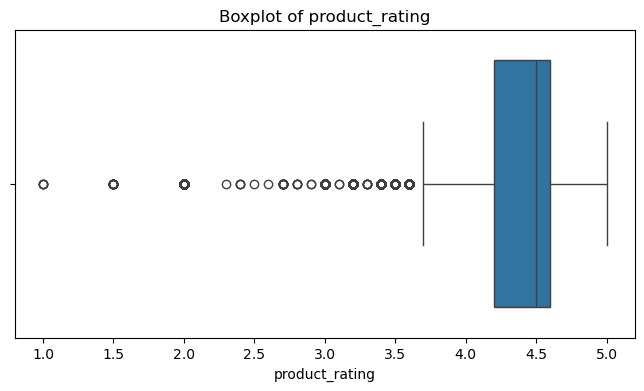

In [32]:
plt.figure(figsize=(8,4))
sns.boxplot(df,x='product_rating')
plt.title("Boxplot of product_rating")
plt.show()

- The median product rating is around 4.5, indicating that at least 50% of the products have ratings above 4.5. This suggests generally positive customer satisfaction
- Most products have ratings between approximately 4.2 and 4.6
- A small number of products received unusually low ratings, These outliers represent genuine customer feedback rather than data errors. Therefore, they provide valuable business information and were retained

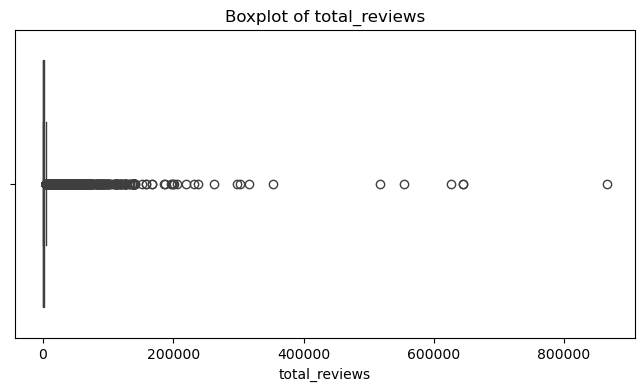

In [33]:
#total_reviews
plt.figure(figsize=(8,4))
sns.boxplot(df,x='total_reviews')
plt.title("Boxplot of total_reviews")
plt.show()

**Observation**
- The boxplot shows that the total_reviews feature contains a large number of high-value outliers and is highly positively skewed. Most products have relatively low review counts, while a small number of products receive exceptionally high customer engagement. Since these outliers represent genuine high-performing products rather than errors, they were retained. This observation also justified the use of median imputation during data cleaning.

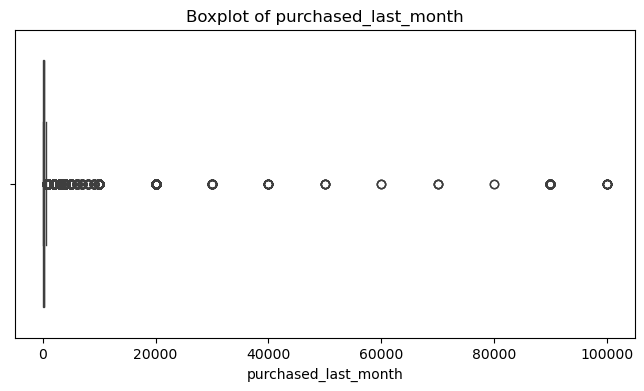

In [34]:
plt.figure(figsize=(8,4))
sns.boxplot(df,x='purchased_last_month')
plt.title("Boxplot of purchased_last_month")
plt.show()

**obseration:**
- The boxplot shows that the purchased_last_month feature has many extreme high values
- This means most people bought small amounts, a few bought huge amounts,making the data highly positively skewed

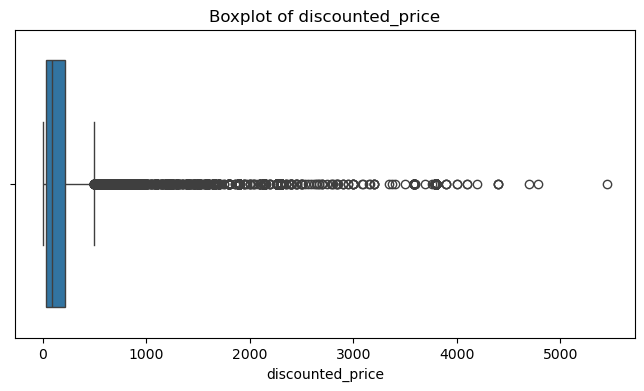

In [35]:
plt.figure(figsize=(8,4))
sns.boxplot(df,x='discounted_price')
plt.title("Boxplot of discounted_price")
plt.show()

**Observation:**
- The boxplot shows that the discounted_price feature contains a large number of high-value outliers and is highly positively skewed. Most products are sold at relatively low discounted prices, while a smaller number of products have exceptionally high discounted prices.

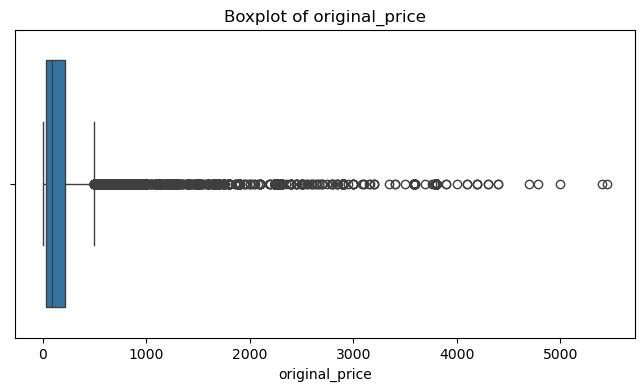

In [36]:
plt.figure(figsize=(8,4))
sns.boxplot(df,x='original_price')
plt.title("Boxplot of original_price")
plt.show()

**observation**
- The boxplot shows that the original_price feature contains a large number of high-value outliers and is highly positively skewed. Most products are priced at relatively low original values, while a smaller number of products have exceptionally high original prices.

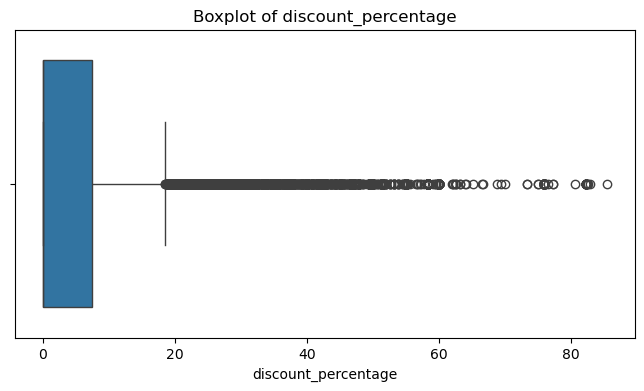

In [37]:
plt.figure(figsize=(8,4))
sns.boxplot(df,x='discount_percentage')
plt.title("Boxplot of discount_percentage")
plt.show()

**Observation**:
- The boxplot shows that the discount_percentage feature contains several high-value outliers and is positively skewed. Most products have relatively low discount percentages (around 0–10%), while a smaller number of products offer exceptionally high discounts, reaching up to 90%.

# Feature Engineering
- New analytical features are created to support deeper business analysis.

**Discount Amount Calculation**
- A new feature called **discounted amount** is created by calculating the difference between original price and discounted price.
- This helps quantify the absolute monetary reduction offered on each product and enables deeper analysis of how discount size impacts estimated revenue performance.
- For example: if a product’s original price is ₹1000 and the discount percentage is 20%, the absolute reduction is ₹200.
- This helps you analyze whether bigger discounts lead to higher estimated revenue (because more customers might buy when discounts are large).

In [38]:
df["discounted_amount"]=df["original_price"]-df["discounted_price"]

**Estimated Revenue Calculation**
- Estimated revenue is approximated using discounted selling price multiplied by purchase frequency.
- This provides a proxy measure for product-level sales performance.

In [39]:
df["estimated_revenue"]=df["discounted_price"]*df["purchased_last_month"]

**Observation**:
Estimated revenue enables business-level performance evaluation by combining product pricing and customer engagement indicators, allowing stronger revenue-driven decision making.

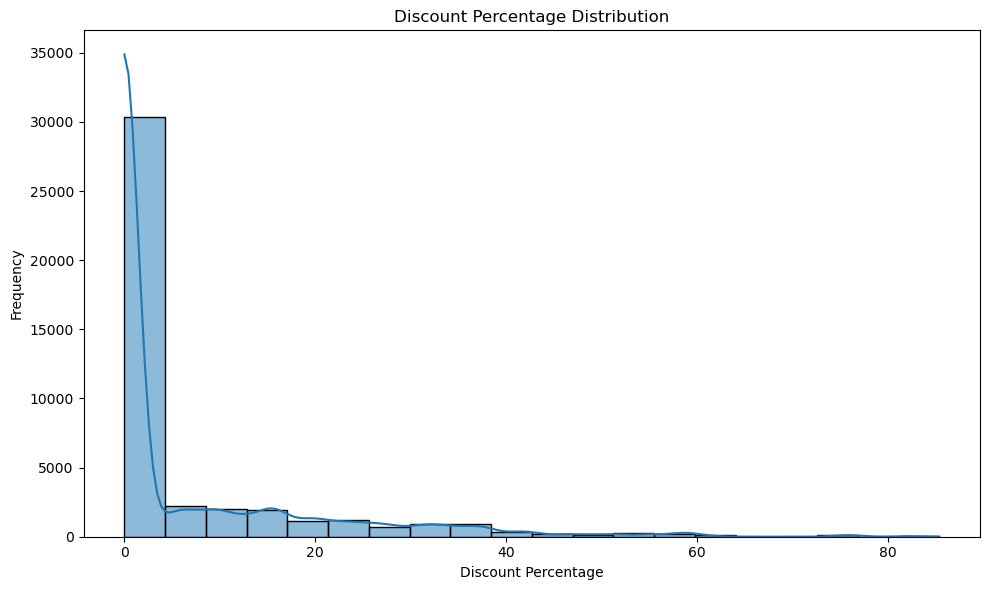

In [40]:
plt.figure(figsize=(10,6))
sns.histplot(df['discount_percentage'], bins=20, kde=True)
plt.title("Discount Percentage Distribution")
plt.xlabel("Discount Percentage")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insight:
Most products fall within moderate discount ranges, indicating that Amazon primarily applies balanced pricing strategies. Extremely high discounting appears less frequent, suggesting that aggressive discounting is used selectively rather than broadly.

**Discount Band Categorization**
- Discount percentages are grouped into categorical bands to compare revenue performance across pricing strategies.

In [41]:
df['discount_percentage_band'] = pd.cut(x = df['discount_percentage'], 
                              bins = [-1,0, 10, 40, 70, 99],
                              labels = ["No discount","Less discount", "Medium discount", "High", "very High"])

In [42]:
df.columns

Index(['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'discount_percentage',
       'product_title', 'is_best_seller', 'is_sponsored', 'has_coupon',
       'buy_box_availability', 'delivery_date', 'product_image_url',
       'product_page_url', 'data_collected_at', 'product_category',
       'discounted_amount', 'estimated_revenue', 'discount_percentage_band'],
      dtype='object')

### Insight:
Most products are concentrated within moderate discount ranges, showing that balanced discount strategies are commonly used to attract customers without heavily impacting profit margins.

- Regarding my target variable(Estimated Revenue), i have to find the 
- summary nd distribution
- Impact of discounts
- product features
- customer Engagement
- category Insights
- Time based Trends

**Distribution of revenue**

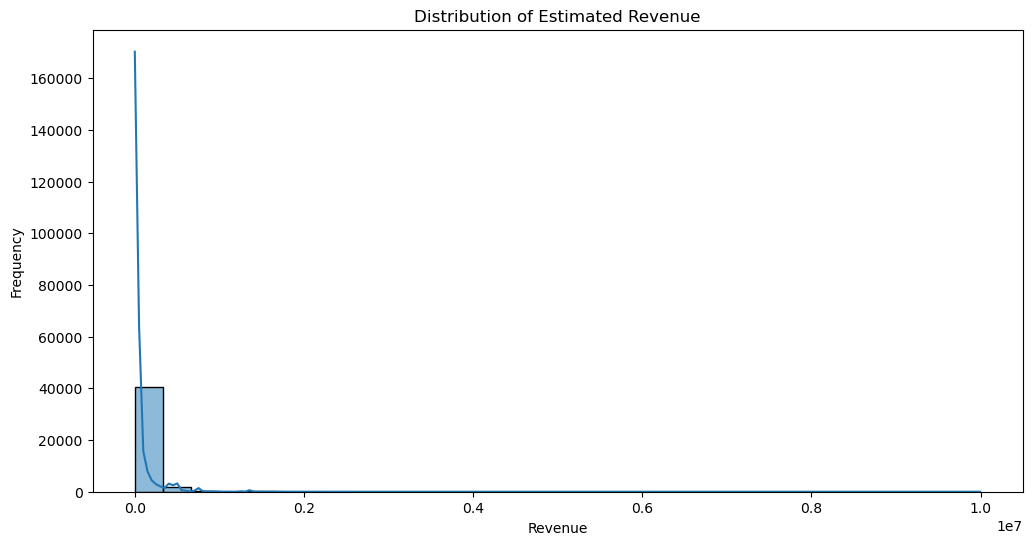

In [43]:
plt.figure(figsize=(12,6))
sns.histplot(df["estimated_revenue"], bins=30, kde=True)
plt.title("Distribution of Estimated Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()



- Estimated revenue is highly right-skewed, indicating a small number of products contribute disproportionately to total revenue.

**Revenue OUtlier Boxplot**

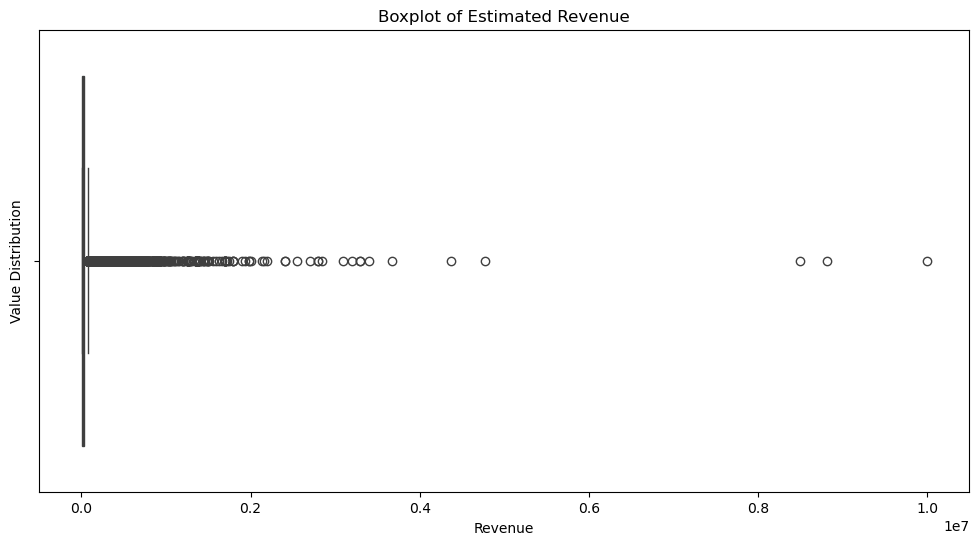

In [44]:
plt.figure(figsize=(12,6))
sns.boxplot(x=df["estimated_revenue"])
plt.title("Boxplot of Estimated Revenue")
plt.xlabel("Revenue")
plt.ylabel("Value Distribution")
plt.show()


- Several high-performing revenue outliers suggest a small subset of products significantly outperform the broader product population.

**Revenue by Category**
- Revenue varies across product categories, suggesting category-specific demand concentration.

In [45]:
# Revenue by category
df.groupby('product_category')['estimated_revenue'].sum().sort_values(ascending=False)


product_category
Laptops                773792018.0
Power & Batteries      553954222.5
Phones                 339677469.0
Cameras                306317867.5
Other Electronics      260450268.0
TV & Display           111902728.0
Storage                 65952892.5
Networking              46720447.5
Speakers                46677236.5
Chargers & Cables       43615427.5
Smart Home              30946937.5
Printers & Scanners     24330567.0
Wearables               20828244.5
Headphones              20168944.5
Gaming                  16003135.0
Name: estimated_revenue, dtype: float64

**Revenue across Discount Distribution**


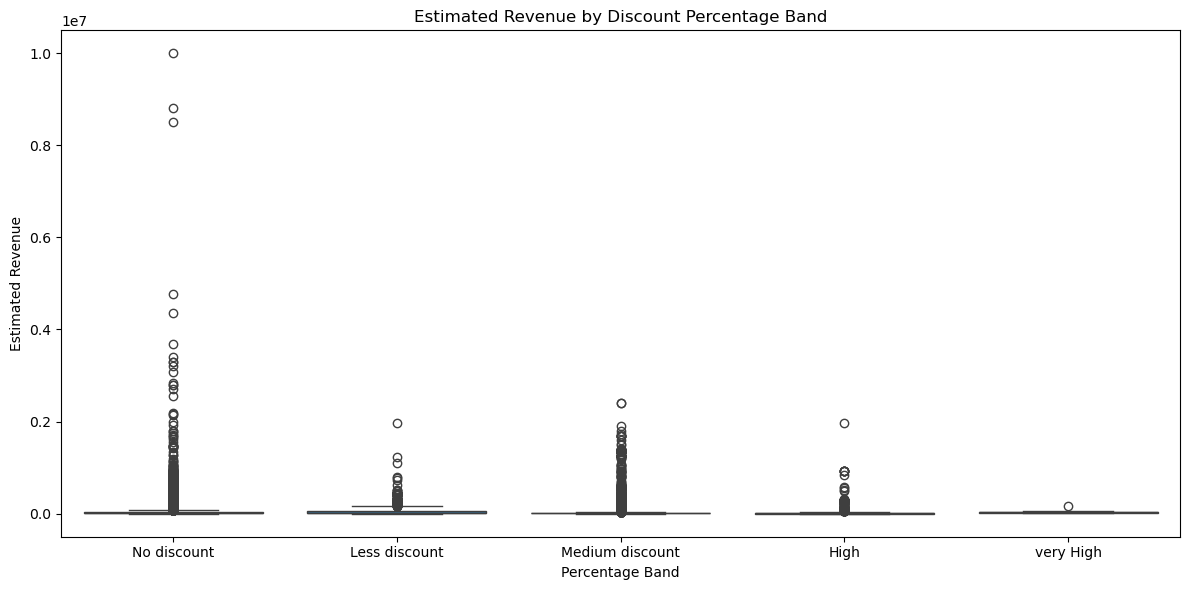

In [46]:
#-------------------
#Impact of Discounts
#---------------------
# Revenue across discount bands
plt.figure(figsize=(12,6))
sns.boxplot(df,x="discount_percentage_band", y="estimated_revenue")
plt.title("Estimated Revenue by Discount Percentage Band")
plt.xlabel("Percentage Band")
plt.ylabel("Estimated Revenue")
plt.tight_layout()
plt.show()


- Products with no discount display the highest estimated revenue outliers, suggesting strong-performing products rely more on product value and customer trust than discounting.

### Insight:
- Some products sell well without discounts
- Demand may be driven by:
- strong brand reputation
- customer loyalty
- product necessity
- high perceived value

**Average Revenue by Discount Band**

In [50]:
avg_revenue=df.groupby('discount_percentage_band',observed=True)['estimated_revenue'].mean().reset_index()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   product_rating            42675 non-null  float64       
 1   total_reviews             42675 non-null  int64         
 2   purchased_last_month      42675 non-null  int64         
 3   discounted_price          42675 non-null  float64       
 4   original_price            42675 non-null  float64       
 5   discount_percentage       42675 non-null  float64       
 6   product_title             42675 non-null  object        
 7   is_best_seller            42675 non-null  object        
 8   is_sponsored              42675 non-null  object        
 9   has_coupon                42675 non-null  object        
 10  buy_box_availability      42675 non-null  object        
 11  delivery_date             42675 non-null  datetime64[ns]
 12  product_image_url 

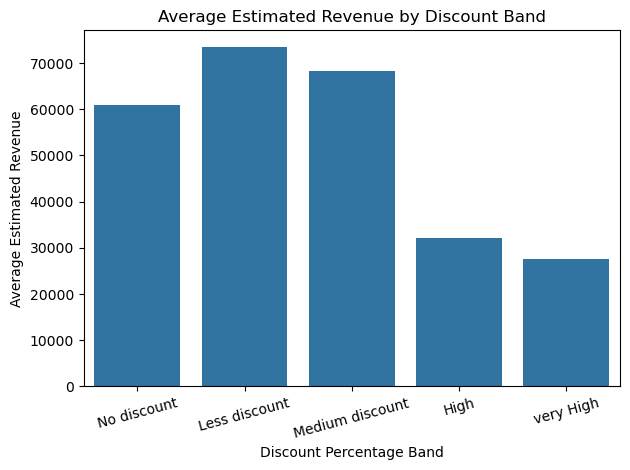

In [48]:
#visualisation
sns.barplot(data=avg_revenue,x='discount_percentage_band',y='estimated_revenue')
plt.title("Average Estimated Revenue by Discount Band")
plt.xlabel("Discount Percentage Band")
plt.ylabel("Average Estimated Revenue")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

- Discounting does not consistently improve revenue performance across all product groups.

**Discount Amount vs Revenue Scatterplot**
- Revenue does not increase proportionally with discount value, suggesting larger discounts alone do not guarantee stronger sales outcomes.

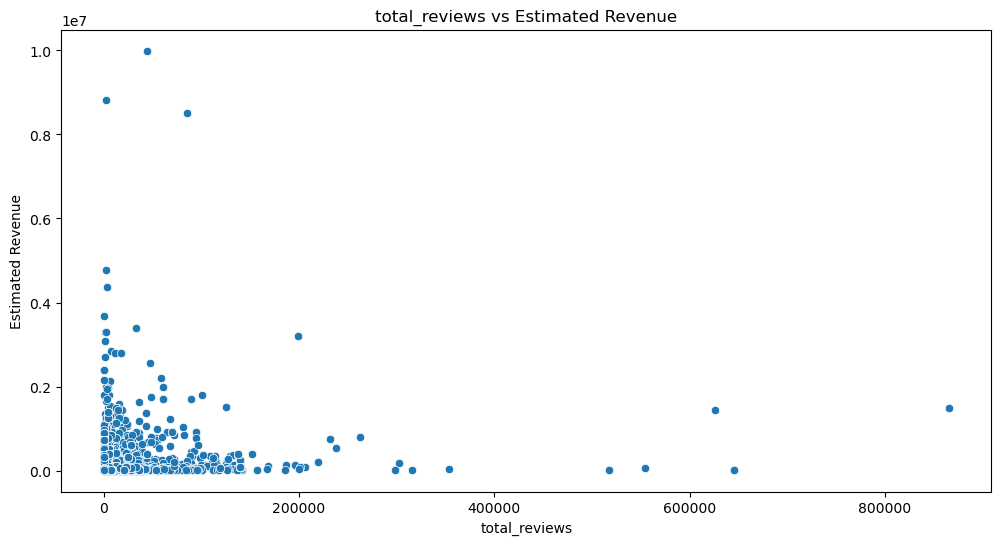

In [52]:
# Relationship between discounted_amount and revenue
plt.figure(figsize=(12,6))
#sns.scatterplot(df,x="discounted_amount", y="estimated_revenue")
sns.scatterplot(df,x="total_reviews", y="estimated_revenue")
plt.title("total_reviews vs Estimated Revenue")
plt.xlabel("total_reviews")
plt.ylabel("Estimated Revenue")
plt.show()


**Observation**
- Even products with very few reviews can generate good revenue, while products with millions of reviews don't always earn more — so review count alone doesn't guarantee sales

In [ ]:
#----------------
#product Features
#----------------
# Bestseller vs non-bestseller
df.groupby('is_best_seller')['estimated_revenue'].mean()


In [ ]:
# Sponsored vs non-sponsored
df.groupby('is_sponsored')['estimated_revenue'].mean()

In [ ]:
# Coupon availability
df.groupby('has_coupon')['estimated_revenue'].mean()

In [ ]:
# Buy box availability
df.groupby('buy_box_availability')['estimated_revenue'].mean()

**Product Rating Distribution**
- This visualization examines the overall distribution of product ratings to understand customer satisfaction patterns across products.

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(df,x="product_rating",bins=20,kde=True)
plt.title("Product Rating Distribution", fontsize=14)
plt.xlabel("Product Rating", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

- Product ratings are concentrated in higher ranges, indicating generally positive customer satisfaction across listed products. Strong customer ratings may contribute to improved purchase confidence and stronger revenue performance.

**Review vs Revenue**

In [ ]:
#------------------
#Customer Engagement
#-------------------
# Correlation between reviews and revenue
plt.figure(figsize=(12,6))
sns.scatterplot(df,x='total_reviews', y='estimated_revenue')
plt.title("Discounted Amount vs Estimated Revenue")
plt.xlabel("Discounted Amount")
plt.ylabel("Estimated Revenue")
plt.show()


- Most points show that smaller discounted amounts correspond to lower estimated revenues.
- A few products with higher discounts achieve much larger revenues, highlighting a skewed relationship.

**Correlation Analysis**
- It is important because,Correlation analysis helps identify how strongly two variables are related.
- It reveals whether increases in one factor (like discounts) are linked to changes in another (like revenue).

In [ ]:
# Correlation coefficient
df[['total_reviews','estimated_revenue']].corr()

**observation**
- The correlation matrix shows a weak positive relationship (0.16) between total_reviews and estimated_revenue.
- This means products with more reviews tend to have slightly higher revenue, but the link is not strong.

In [ ]:
# Ratings vs revenue
plt.figure(figsize=(12,6))
sns.boxplot(x="product_rating", y="estimated_revenue", data=df)
plt.title("Estimated Revenue by Product Rating")
plt.xlabel("Product Rating")
plt.ylabel("Estimated Revenue")
plt.xticks(rotation=45)
plt.show()

**Observation**
- Products with higher ratings generally show higher estimated revenues.
- Outliers at ratings above 4.5 highlight that top‑rated items can generate exceptionally large revenue.

In [ ]:
#-----------------------
#Category Insights
#----------------------
# Total revenue by category
df.groupby('product_category')['estimated_revenue'].sum().sort_values(ascending=False)

In [ ]:
# Revenue by category and discount band
df.groupby(['product_category','discount_percentage_band'],observed=True)['estimated_revenue'].mean().unstack()

**Observation**
- Different product categories respond differently to discount levels, with some showing higher values under medium or high discounts.
- Power & Batteries and Smart Home stand out, generating strong values at higher discount bands compared to other categories.
- For Example, With No discount, laptops generate about 97,928 in value.
- Under a Less discount, the value rises to 124,205, showing that small discounts can boost sales.
- At Medium discount, the value drops to 46,924, meaning moderate discounts don’t perform as well.
- At High discount, it’s 55,214, slightly better but still lower than small discounts.
- With Very High discount, laptops generate 36,989, showing that very steep discounts reduce overall revenue contribution. 

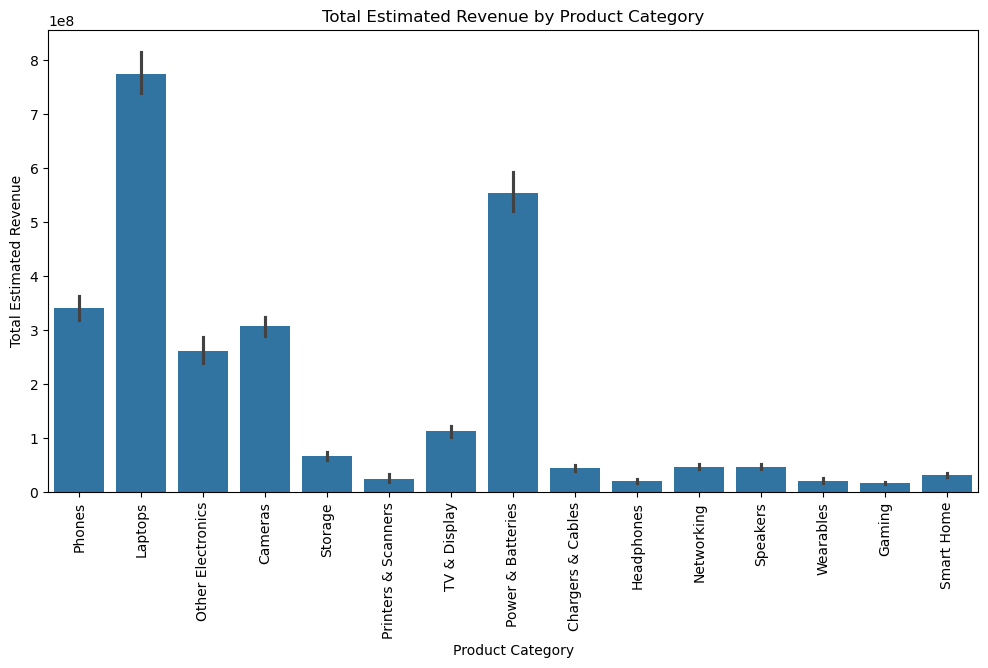

In [53]:
# Visualization

plt.figure(figsize=(12,6))
sns.barplot(x="product_category", y="estimated_revenue", data=df, estimator=sum)
plt.title("Total Estimated Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Estimated Revenue")
plt.xticks(rotation=90)
plt.show()

In [ ]:
#--------------------
#Time Based Trends
#--------------------
# Convert to datetime
df['data_collected_at'] = pd.to_datetime(df['data_collected_at'], errors='coerce')

**Daily Revenue Trend**

In [ ]:
# Revenue trend over time
plt.figure(figsize=(12,6))
df.groupby(df["data_collected_at"].dt.date)["estimated_revenue"].sum().plot(kind="line")
plt.title("Daily Total Estimated Revenue")
plt.xlabel("Date Collected")
plt.ylabel("Total Estimated Revenue")
plt.xticks(rotation=90)
plt.show()

**Observation**
- Daily revenue dropped sharply from about 900 million to 280 million between August 21–24.
- After that fall, revenue gradually recovered with slight fluctuations through August 30.

- Revenue fluctuations suggest changing demand behavior influenced by time-sensitive market dynamics.

**Delivery Impact Analysis**

In [ ]:
# Delivery date impact
plt.figure(figsize=(12,6))
sns.boxplot(x="delivery_date", y="estimated_revenue", data=df)
plt.title("Estimated Revenue by Delivery Date")
plt.xlabel("Delivery Date")
plt.ylabel("Estimated Revenue")
plt.xticks(rotation=90)
plt.show()

**Observation**
- Delivery speed appears to influence purchasing behavior and revenue performance.
- Revenue varies across delivery dates, with most dates showing moderate values.
- Certain dates like August 29 and September 1 stand out with unusually high and more variable revenue.

**Correlation Heatmap**

In [ ]:
#finding correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(),
                                    annot=True,
                                    cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Observation**
- Discounted price and original price show a very strong positive correlation (0.97).
- Purchased_last_month and estimated_revenue have a moderate positive correlation (0.6), indicating sales activity links to revenue growth.

- Revenue is influenced by multiple interacting factors including pricing, customer engagement, and product visibility.
### Key Findings from Correlation Analysis
- Estimated revenue shows positive correlation with:
  - purchased_last_month
  - discounted_price
  - total_reviews
- Discount percentage has weak correlation with revenue, suggesting discounts alone do not guarantee higher sales.

## Final Conclusion
- Key findings from the analysis:
- Moderate discount strategies perform better than aggressive discounting.
- Customer engagement indicators such as reviews strongly influence revenue.
- Certain product categories dominate total sales contribution.
- High-rated products tend to generate stronger revenue performance.
- Revenue distribution is highly skewed, with a small group of products contributing most sales.

## Business Recommendations:
- Focus on customer satisfaction and reviews.
- Use strategic discounts instead of excessive discounting.
- Promote high-performing categories more aggressively.
- Improve delivery experience to support customer retention.

# Target variable Explaination


- Estimated revenue is not actual company revenue but an approximated metric derived using available pricing and purchase frequency data.

In [ ]:
# we can also go with advanced 

In [ ]:
sns.pairplot(df[["discounted_price",
                 "product_rating",
                 "total_reviews",
                 "estimated_revenue"]])

In [ ]:
#Top 10 revenue products
top_products = df.sort_values(
    by="estimated_revenue",
    ascending=False
).head(10)
top_products

In [ ]:
#category wise avg rating
df.groupby("product_category")["product_rating"].mean()